# Vision Transformer from Scratch — CIFAR-10

Implementation and training of a Vision Transformer (patch embedding, CLS token,
positional embeddings, multi-head self-attention, MLP, residual connections,
LayerNorm — all implemented from scratch, no pre-built Transformer/ViT/attention
modules) for 10-class classification on CIFAR-10, trained from random initialization
with no pretrained weights.

## Results Summary

| Model | Patch Config | Val Acc | **Test Acc** |
|---|---|---|---|
| ViT (baseline) | 4x4 non-overlapping patches | 81.78% | **81.93%** |
| ViT (overlapping patches) | 8x8 kernel / stride 4 (50% overlap) | 84.08% | **83.54%** |

Full run instructions, configuration, and analysis are in `README.md`.


## 1. Setup & Reproducibility

In [1]:
import os
import math
import time
import json
import random

import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt

SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [2]:
# Mount Drive so checkpoints survive session restarts / GPU quota interruptions
from google.colab import drive
drive.mount('/content/drive')
CHECKPOINT_DIR = "/content/drive/MyDrive/vit_cifar10_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

Mounted at /content/drive


## 2. Configuration

Hyperparameter configurations for training and evaluation. The overlap_patches flag enables the patch projection ablation evaluated in Section 10.

In [3]:
from dataclasses import dataclass

@dataclass
class Config:
    seed: int = 42

    # data
    data_root: str = "./data"
    val_frac: float = 0.1
    batch_size: int = 128
    num_workers: int = 2

    # model
    img_size: int = 32
    patch_size: int = 4
    in_channels: int = 3
    embed_dim: int = 256
    depth: int = 6
    num_heads: int = 8
    mlp_ratio: float = 4.0
    dropout: float = 0.1
    num_classes: int = 10
    overlap_patches: bool = False   # extra-credit toggle

    # training
    epochs: int = 100
    lr: float = 3e-4
    weight_decay: float = 0.05

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

## 3. Data

Train split uses `RandomCrop(32, padding=4)` + `RandomHorizontalFlip()` — standard,
lightweight regularization needed because a from-scratch ViT (no convolutional
inductive bias) overfits quickly on CIFAR-10's 45k training images without it.
Validation and test use no augmentation, so reported numbers are clean.

The test split is held out and evaluated strictly once using the checkpoint with the highest validation accuracy to prevent data leakage during hyperparameter selection.

In [4]:
def get_dataloaders(cfg: Config):
    train_transform = T.Compose([
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize(CIFAR_MEAN, CIFAR_STD),
    ])
    eval_transform = T.Compose([
        T.ToTensor(),
        T.Normalize(CIFAR_MEAN, CIFAR_STD),
    ])

    full_train_aug = torchvision.datasets.CIFAR10(
        root=cfg.data_root, train=True, download=True, transform=train_transform)
    full_train_eval = torchvision.datasets.CIFAR10(
        root=cfg.data_root, train=True, download=True, transform=eval_transform)
    test_set = torchvision.datasets.CIFAR10(
        root=cfg.data_root, train=False, download=True, transform=eval_transform)

    val_size = int(len(full_train_aug) * cfg.val_frac)
    train_size = len(full_train_aug) - val_size
    split_gen = torch.Generator().manual_seed(cfg.seed)
    train_idx, val_idx = random_split(range(len(full_train_aug)), [train_size, val_size],
                                       generator=split_gen)

    train_set = Subset(full_train_aug, train_idx.indices)
    val_set = Subset(full_train_eval, val_idx.indices)  # no augmentation on val

    loader_gen = torch.Generator().manual_seed(cfg.seed)
    train_loader = DataLoader(train_set, batch_size=cfg.batch_size, shuffle=True,
                               num_workers=cfg.num_workers, generator=loader_gen, drop_last=True)
    val_loader = DataLoader(val_set, batch_size=cfg.batch_size, shuffle=False,
                             num_workers=cfg.num_workers)
    test_loader = DataLoader(test_set, batch_size=cfg.batch_size, shuffle=False,
                              num_workers=cfg.num_workers)
    return train_loader, val_loader, test_loader

## 4. Patch Embedding

32x32 images are split into 4x4 patches -> 64 patches, each linearly projected to
`embed_dim`. A `Conv2d(kernel=stride=patch_size)` performs "chop into non-overlapping
patches + linear-project each" in a single op this is a permitted basic layer, not
a pre-built Transformer/ViT component.

A learnable CLS token is prepended (its output is what the classification head
reads), and learnable positional embeddings are added since attention itself is
permutation-invariant and has no notion of patch order.

`overlap` (extra-credit toggle, Section 8): uses `kernel=2*patch_size, stride=patch_size,
padding=patch_size//2` instead, so neighboring patches share 50% of their pixels
while the resulting grid size  and therefore total token count  stays identical
to the non-overlapping case (64 patches), keeping the comparison controlled.

In [5]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim, dropout, overlap=False):
        super().__init__()
        if overlap:
            kernel_size, stride, padding = patch_size * 2, patch_size, patch_size // 2
        else:
            kernel_size, stride, padding = patch_size, patch_size, 0

        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=kernel_size,
                               stride=stride, padding=padding)

        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, img_size, img_size)
            grid = self.proj(dummy).shape[-1]
        self.grid_size = grid
        self.num_patches = grid ** 2

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x)                      # (B, embed_dim, grid, grid)
        x = x.flatten(2).transpose(1, 2)       # (B, num_patches, embed_dim)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # (B, num_patches+1, embed_dim)
        x = x + self.pos_embed
        return self.dropout(x)

## 5. Multi-Head Self-Attention (from scratch)

Q/K/V are computed via a single combined linear projection then split into
`num_heads` heads. Attention scores are the scaled dot product `(Q K^T) / sqrt(d_k)`
— scaling prevents large-magnitude dot products from pushing softmax into
near-zero-gradient regions — followed by softmax and a weighted sum over V.
Heads are then merged and passed through an output projection.

The self-attention mechanism is implemented directly via matrix operations to allow full control over head splitting, scaling, and score aggregation.

In [6]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=True)
        self.attn_dropout = nn.Dropout(dropout)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.out_dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape
        H, d = self.num_heads, self.head_dim

        qkv = self.qkv(x).reshape(B, N, 3, H, d).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]                       # (B, H, N, d)

        attn_scores = (q @ k.transpose(-2, -1)) * self.scale   # (B, H, N, N)
        attn_weights = attn_scores.softmax(dim=-1)
        attn_weights = self.attn_dropout(attn_weights)

        out = (attn_weights @ v).transpose(1, 2).reshape(B, N, D)
        out = self.out_proj(out)
        return self.out_dropout(out)

## 6. LayerNorm (from scratch) & MLP

LayerNorm normalizes each token's feature vector independently (mean/var computed
over the embedding dimension, per token) — unlike BatchNorm, it has no dependency on
batch composition, which is why it's the standard choice for sequence models.
Implemented manually below (no `nn.LayerNorm`).

The MLP is a standard 2-layer position-wise feedforward block (expand -> GELU ->
project back), applied identically and independently to every token.

In [7]:
class LayerNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(dim))
        self.beta = nn.Parameter(torch.zeros(dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_norm + self.beta


class MLP(nn.Module):
    def __init__(self, embed_dim, mlp_ratio, dropout):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return self.dropout(x)

## 7. Transformer Encoder Block & Full ViT

Pre-LN residual block: `x = x + Attention(LN(x))`, then `x = x + MLP(LN(x))`.
Pre-LN (normalize before the sublayer) keeps a clean residual gradient path and is
more stable to train than Post-LN, especially without a hand-tuned warmup schedule —
this is the standard choice in ViT and modern Transformers generally.

The full model stacks `depth` encoder blocks, applies a final LayerNorm, then
classifies using **only the CLS token's** final representation (the other 64 patch
tokens are discarded at this point) through a single linear head.

In [8]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio, dropout):
        super().__init__()
        self.norm1 = LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_ratio, dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class VisionTransformer(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.patch_embed = PatchEmbedding(
            cfg.img_size, cfg.patch_size, cfg.in_channels, cfg.embed_dim,
            cfg.dropout, overlap=cfg.overlap_patches)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(cfg.embed_dim, cfg.num_heads, cfg.mlp_ratio, cfg.dropout)
            for _ in range(cfg.depth)
        ])

        self.norm = LayerNorm(cfg.embed_dim)
        self.head = nn.Linear(cfg.embed_dim, cfg.num_classes)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, (nn.Linear, nn.Conv2d)):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.patch_embed(x)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        cls_out = x[:, 0]           # CLS token only
        return self.head(cls_out)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 8. Training & Evaluation Utilities

- **Loss**: `CrossEntropyLoss` on raw logits.
- **Optimizer**: `AdamW` — decouples weight decay from the gradient update (plain
  Adam's weight decay is effectively broken), the standard choice for Transformers.
- **LR schedule**: linear warmup (5 epochs) then cosine decay — Transformers are
  unstable at high LR early on since attention weights start near-random; warmup
  avoids this, cosine decay settles training smoothly by the end.
- **Gradient clipping** (max norm 1.0) as cheap protection against loss spikes.
- **Model selection on validation accuracy** — the checkpoint is saved only when
  validation accuracy improves, and that checkpoint (not the last epoch) is what
  gets evaluated on the test set.

In [9]:
def get_lr_scheduler(optimizer, warmup_epochs, total_epochs, steps_per_epoch):
    warmup_steps = warmup_epochs * steps_per_epoch
    total_steps = total_epochs * steps_per_epoch

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


def train_one_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


def train(cfg: Config, checkpoint_path, resume=False):
    set_seed(cfg.seed)
    train_loader, val_loader, _ = get_dataloaders(cfg)
    model = VisionTransformer(cfg).to(device)
    print(f"Model parameters: {count_params(model):,}")

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = get_lr_scheduler(optimizer, warmup_epochs=5, total_epochs=cfg.epochs,
                                  steps_per_epoch=len(train_loader))

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    start_epoch, best_val_acc = 0, 0.0

    if resume and os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        start_epoch = ckpt["epoch"] + 1
        best_val_acc = ckpt["best_val_acc"]
        history = ckpt.get("history", history)
        print(f"Resumed from epoch {start_epoch}, best_val_acc={best_val_acc:.4f}")

    for epoch in range(start_epoch, cfg.epochs):
        start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        elapsed = time.time() - start

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "epoch": epoch,
                "best_val_acc": best_val_acc,
                "history": history,
            }, checkpoint_path)

        print(f"Epoch {epoch+1:3d}/{cfg.epochs} | train_loss {train_loss:.4f} acc {train_acc:.4f} | "
              f"val_loss {val_loss:.4f} acc {val_acc:.4f} | best_val_acc {best_val_acc:.4f} | {elapsed:.1f}s")

    return model, history, best_val_acc


def final_test_evaluation(cfg: Config, checkpoint_path):
    _, _, test_loader = get_dataloaders(cfg)
    model = VisionTransformer(cfg).to(device)
    ckpt = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"Final Test Loss:     {test_loss:.4f}")
    print(f"Final Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    return test_loss, test_acc


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="val")
    axes[0].set_title(f"{title} — Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
    axes[1].plot(history["train_acc"], label="train")
    axes[1].plot(history["val_acc"], label="val")
    axes[1].set_title(f"{title} — Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"{title.lower().replace(' ', '_')}_curve.png", dpi=150)
    plt.show()

## 9. Baseline Training — Non-Overlapping 4x4 Patches

Training the baseline model with 4x4 non-overlapping patches. Checkpoints are stored per epoch when validation accuracy improves to support resuming in case of hardware timeout.

In [10]:
baseline_cfg = Config()
baseline_ckpt = f"{CHECKPOINT_DIR}/baseline_best_model.pth"

baseline_model, baseline_history, baseline_best_val_acc = train(
    baseline_cfg, checkpoint_path=baseline_ckpt, resume=True)
print(f"\nBaseline — best val acc: {baseline_best_val_acc:.4f}")

100%|██████████| 170M/170M [47:07<00:00, 60.3kB/s]


Model parameters: 4,771,082
Epoch   1/100 | train_loss 1.9968 acc 0.2512 | val_loss 1.8419 acc 0.3052 | best_val_acc 0.3052 | 46.4s
Epoch   2/100 | train_loss 1.7408 acc 0.3539 | val_loss 1.7110 acc 0.3826 | best_val_acc 0.3826 | 45.5s
Epoch   3/100 | train_loss 1.5685 acc 0.4290 | val_loss 1.4394 acc 0.4766 | best_val_acc 0.4766 | 45.8s
Epoch   4/100 | train_loss 1.4328 acc 0.4791 | val_loss 1.3551 acc 0.5070 | best_val_acc 0.5070 | 45.8s
Epoch   5/100 | train_loss 1.3577 acc 0.5032 | val_loss 1.2726 acc 0.5432 | best_val_acc 0.5432 | 45.8s
Epoch   6/100 | train_loss 1.3003 acc 0.5274 | val_loss 1.2506 acc 0.5460 | best_val_acc 0.5460 | 45.8s
Epoch   7/100 | train_loss 1.2387 acc 0.5483 | val_loss 1.1699 acc 0.5756 | best_val_acc 0.5756 | 45.8s
Epoch   8/100 | train_loss 1.1835 acc 0.5717 | val_loss 1.1072 acc 0.6020 | best_val_acc 0.6020 | 45.8s
Epoch   9/100 | train_loss 1.1320 acc 0.5919 | val_loss 1.0420 acc 0.6264 | best_val_acc 0.6264 | 45.8s
Epoch  10/100 | train_loss 1.0832 ac

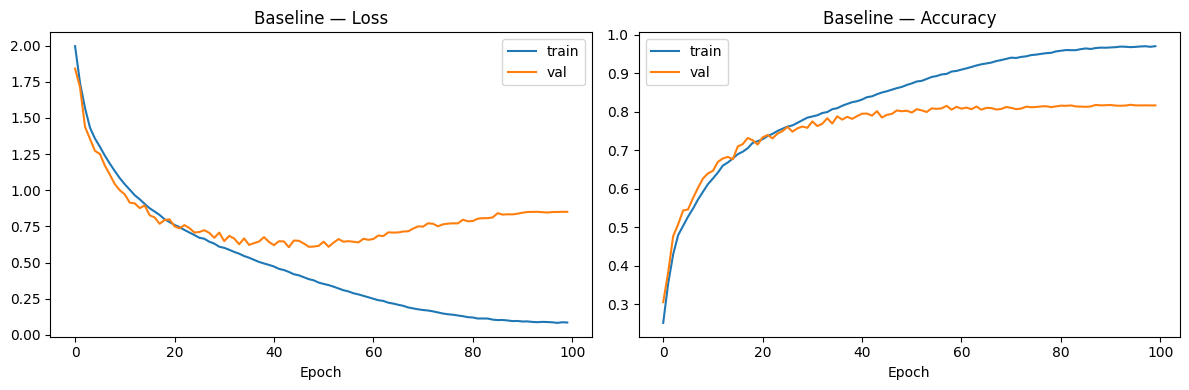

Final Test Loss:     0.8472
Final Test Accuracy: 0.8193 (81.93%)


In [11]:
plot_history(baseline_history, "Baseline")

with open(f"{CHECKPOINT_DIR}/baseline_history.json", "w") as f:
    json.dump(baseline_history, f)

baseline_test_loss, baseline_test_acc = final_test_evaluation(baseline_cfg, baseline_ckpt)

## 10. Extra-Credit Experiment — Overlapping Patch Embeddings

**Hypothesis:** non-overlapping 4x4 patches create hard boundaries — pixels adjacent
in the real image but on opposite sides of a patch edge share no context, which can
fragment small discriminative features (edges, textures) exactly where they're cut.
Overlapping patches (`kernel=8, stride=4`, 50% pixel overlap between neighbors) let
boundary regions appear in two neighboring tokens instead of being arbitrarily split.

**Controlled comparison:** identical depth, heads, embed_dim, dropout, LR schedule,
seed, augmentation, and — critically — identical token count (64 patches, verified
by construction in `PatchEmbedding`). Only what pixel region each patch token is
computed from differs. Global self-attention is unchanged; only the quality of the
per-token representation going into it changes.

In [12]:
overlap_cfg = Config()
overlap_cfg.overlap_patches = True
overlap_ckpt = f"{CHECKPOINT_DIR}/overlap_best_model.pth"

overlap_model, overlap_history, overlap_best_val_acc = train(
    overlap_cfg, checkpoint_path=overlap_ckpt, resume=True)
print(f"\nOverlap variant — best val acc: {overlap_best_val_acc:.4f}")

Model parameters: 4,807,946
Epoch   1/100 | train_loss 1.9801 acc 0.2596 | val_loss 1.8024 acc 0.3266 | best_val_acc 0.3266 | 45.5s
Epoch   2/100 | train_loss 1.7010 acc 0.3669 | val_loss 1.6344 acc 0.4160 | best_val_acc 0.4160 | 45.4s
Epoch   3/100 | train_loss 1.5499 acc 0.4328 | val_loss 1.5261 acc 0.4610 | best_val_acc 0.4610 | 45.6s
Epoch   4/100 | train_loss 1.4459 acc 0.4745 | val_loss 1.3739 acc 0.4998 | best_val_acc 0.4998 | 45.5s
Epoch   5/100 | train_loss 1.3761 acc 0.4990 | val_loss 1.3368 acc 0.5292 | best_val_acc 0.5292 | 45.5s
Epoch   6/100 | train_loss 1.3124 acc 0.5250 | val_loss 1.2662 acc 0.5466 | best_val_acc 0.5466 | 45.7s
Epoch   7/100 | train_loss 1.2470 acc 0.5463 | val_loss 1.2043 acc 0.5746 | best_val_acc 0.5746 | 46.5s
Epoch   8/100 | train_loss 1.1963 acc 0.5699 | val_loss 1.1579 acc 0.5932 | best_val_acc 0.5932 | 46.8s
Epoch   9/100 | train_loss 1.1563 acc 0.5851 | val_loss 1.0841 acc 0.6168 | best_val_acc 0.6168 | 46.0s
Epoch  10/100 | train_loss 1.1142 ac

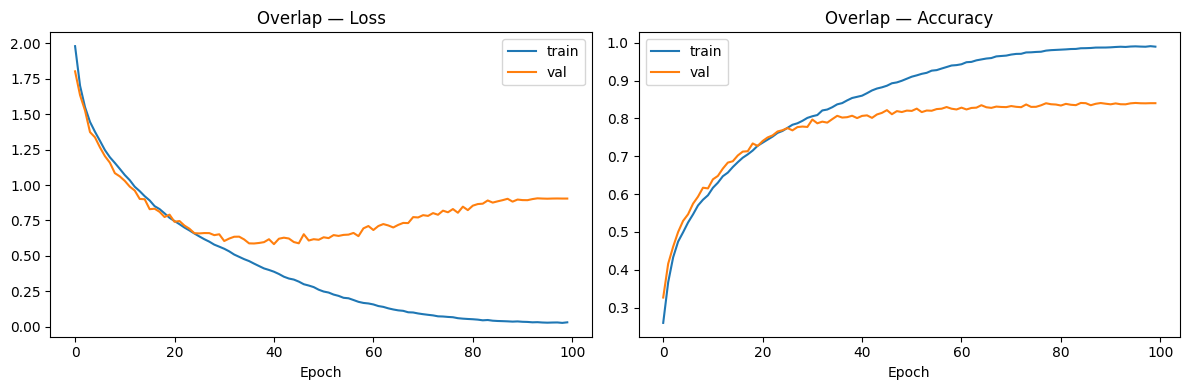

Final Test Loss:     0.8617
Final Test Accuracy: 0.8354 (83.54%)


In [13]:
plot_history(overlap_history, "Overlap")

with open(f"{CHECKPOINT_DIR}/overlap_history.json", "w") as f:
    json.dump(overlap_history, f)

overlap_test_loss, overlap_test_acc = final_test_evaluation(overlap_cfg, overlap_ckpt)

## 11. Comparative Analysis

| Variant | Val Acc | Test Acc |
|---|---|---|
| Baseline (non-overlapping patches) | 0.8178 | **0.8193** |
| Overlapping patches | 0.8408 | **0.8354** |

Overlapping patches improved test accuracy by **+1.61pp** in a controlled comparison
(identical architecture, training budget, and seed — only the patch tokenization
changed).

**Why it worked:** non-overlapping patches split visually adjacent pixels into
disjoint tokens with no shared context, which can sever locally discriminative
features (an edge, a wheel outline) exactly at a patch boundary. Overlapping patches
let that boundary information appear in two adjacent tokens, giving each token's
linear projection a more complete local view *before* attention operates on it.
Global self-attention still performs all long-range reasoning unchanged — overlap
only improves the quality of the token-level representations feeding into it. This
is consistent with the motivation behind richer/overlapping tokenization strategies
in later ViT variants (e.g. T2T-ViT).

**Cost:** overlapping patches require slightly more computation in the patch
embedding conv (larger kernel, same stride) — negligible relative to total model
FLOPs, but a real trade-off worth naming.

**Scope:** this result isolates the effect of patch overlap at this specific model
scale (~5M params) and training budget (100 epochs / early-stopped at 86 for the
overlap run due to Colab GPU quota — validation accuracy had already plateaued,
with train accuracy at 98%+, so further epochs were unlikely to help). It does not
establish whether the gain holds at larger scale or longer training.
